In [1]:
"""
Programming Lab 5 - Reading a Classic
PHYS 2511 - Spring 2026
Counts character mentions by chapter in Frankenstein and plots results.
"""

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


In [ ]:

# -- Configuration 
FILE_NAME = "pg84.txt"          

CHARACTERS = [
    "Victor",
    "creature",
    "Agatha",
    "Caroline",
    "De Lacey",
    "Elizabeth",
    "Ernest",
    "Felix",
    "Henry",
    "Justine",
    "William",
]



In [ ]:
# -- Step 1: Read the file 
my_file = open(FILE_NAME, "r", encoding="utf-8")
lines = my_file.readlines()
my_file.close()


In [ ]:

# -- Step 2: Find section headers 

header_indices = []   # list of (line_index, label_string)
prev_blank = False
for i, line in enumerate(lines):
    stripped = line.strip()
    if (prev_blank
            and (stripped.startswith("Letter ") or stripped.startswith("Chapter "))
            and len(stripped.split()) == 2):
        header_indices.append((i, stripped))
    prev_blank = (stripped == "")

# Keep only the last 28 entries (real chapters, not the ToC duplicates)
header_indices = header_indices[-28:]
print("Found headers:")
for i, (line_index, label) in enumerate(header_indices):
    print(f"  {i:2d}: {label} (line {line_index})")


Found headers:
   0: Letter 1 (line 66)
   1: Letter 2 (line 190)
   2: Letter 3 (line 315)
   3: Letter 4 (line 360)
   4: Chapter 1 (line 647)
   5: Chapter 2 (line 813)
   6: Chapter 3 (line 1024)
   7: Chapter 4 (line 1279)
   8: Chapter 5 (line 1515)
   9: Chapter 6 (line 1753)
  10: Chapter 7 (line 2019)
  11: Chapter 8 (line 2388)
  12: Chapter 9 (line 2693)
  13: Chapter 10 (line 2902)
  14: Chapter 11 (line 3125)
  15: Chapter 12 (line 3389)
  16: Chapter 13 (line 3596)
  17: Chapter 14 (line 3800)
  18: Chapter 15 (line 3984)
  19: Chapter 16 (line 4293)
  20: Chapter 17 (line 4607)
  21: Chapter 18 (line 4790)
  22: Chapter 19 (line 5071)
  23: Chapter 20 (line 5322)
  24: Chapter 21 (line 5650)
  25: Chapter 22 (line 6016)
  26: Chapter 23 (line 6357)
  27: Chapter 24 (line 6605)


In [ ]:

# -- Step 3: Build section text 
sections = []   # list of (label, text)
for k, (idx, label) in enumerate(header_indices):
    start = idx + 1
    end = header_indices[k + 1][0] if k + 1 < len(header_indices) else len(lines)
    section_text = " ".join(lines[start:end])
    sections.append((label, section_text))



In [ ]:
# -- Step 4: Count character mentions per section 
counts = {char: [] for char in CHARACTERS}
labels = []

for label, text in sections:
    labels.append(label)
    for char in CHARACTERS:
        counts[char].append(text.count(char))


In [ ]:

# -- Step 5: Print a table
col_w = 12
print(f"{'Section':<14}", end="")
for char in CHARACTERS:
    print(f"{char:>{col_w}}", end="")
print()
print("-" * (14 + col_w * len(CHARACTERS)))

for i, label in enumerate(labels):
    print(f"{label:<14}", end="")
    for char in CHARACTERS:
        print(f"{counts[char][i]:>{col_w}}", end="")
    print()



Section             Victor    creature      Agatha    Caroline    De Lacey   Elizabeth      Ernest       Felix       Henry     Justine     William
--------------------------------------------------------------------------------------------------------------------------------------------------
Letter 1                 0           0           0           0           0           0           0           0           0           0           0
Letter 2                 0           0           0           0           0           0           0           0           0           0           0
Letter 3                 0           0           0           0           0           0           0           0           0           0           0
Letter 4                 0           5           0           0           0           0           0           0           0           0           0
Chapter 1                1           2           0           2           0           4           0           0        

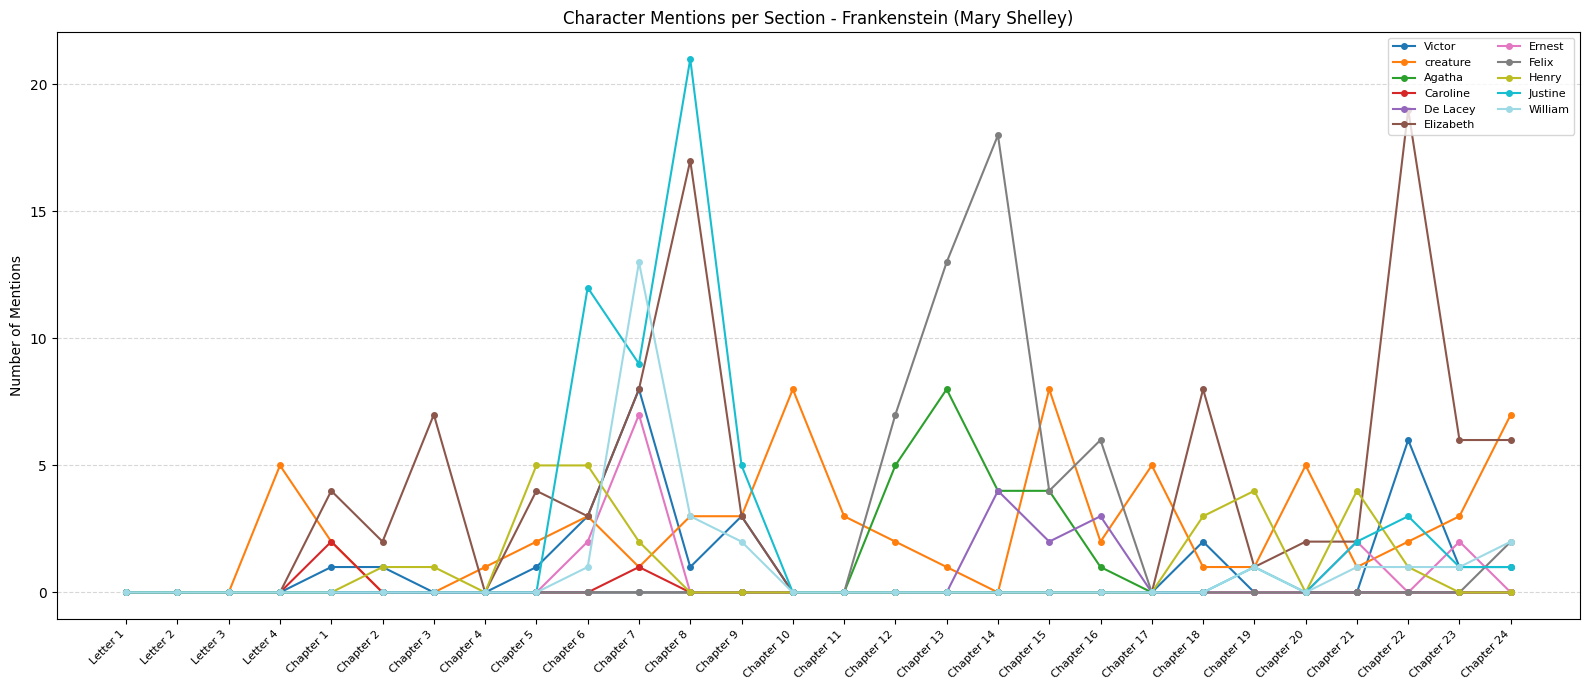


Plot saved to frankenstein_mentions.png


In [ ]:
# -- Step 6: Plot 
colors = cm.tab20(np.linspace(0, 1, len(CHARACTERS)))
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(16, 7))

for idx, char in enumerate(CHARACTERS):
    ax.plot(x, counts[char], marker="o", markersize=4,
            label=char, color=colors[idx], linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of Mentions")
ax.set_title("Character Mentions per Section - Frankenstein (Mary Shelley)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("frankenstein_mentions.png", dpi=150)
plt.show()
print("\nPlot saved to frankenstein_mentions.png")



In [10]:
print("""
=============================================================================
HYPOTHESES BASED ON THE DATA
=============================================================================

Victor Frankenstein
  Victor shows up in almost every chapter. He probably meets everyone in the
  book. He is most likely the main narrator since he is mentioned so consistently.

The Creature
  The creature barely appears early on but spikes in chapters 11-16 and near
  the end. He probably meets Victor but maybe not many others. It looks like
  he plays a big role in the ending.

Elizabeth
  Elizabeth is mentioned a lot starting in chapter 1 all the way through
  chapters 22-23. She is probably close to Victor, maybe a love interest.
  She seems to disappear near the very end so she might die.

Henry (Clerval)
  Henry shows up in the early and middle chapters alongside Victor. He is
  gone by the final chapters. He is probably Victor's friend and might die
  before the end.

William
  William only appears in chapters 7 and 8 then never again. He probably
  dies early and that event is important to the plot.

Justine
  Justine peaks in the exact same chapters as William. She is probably
  connected to whatever happens to him and also disappears after chapter 9.

De Lacey / Agatha / Felix
  These three only show up in chapters 12-16. They seem to be a family group.
  They probably never meet Victor but the creature might know them.

Caroline
  Caroline only shows up in the first chapter or two. She is probably from
  Victor's past and is already dead when the main story starts.

Ernest
  Ernest barely appears in the data. He is probably a minor character who
  does not have much impact on the story.

=============================================================================
""")



HYPOTHESES BASED ON THE DATA

Victor Frankenstein
  Victor shows up in almost every chapter. He probably meets everyone in the
  book. He is most likely the main narrator since he is mentioned so consistently.

The Creature
  The creature barely appears early on but spikes in chapters 11-16 and near
  the end. He probably meets Victor but maybe not many others. It looks like
  he plays a big role in the ending.

Elizabeth
  Elizabeth is mentioned a lot starting in chapter 1 all the way through
  chapters 22-23. She is probably close to Victor, maybe a love interest.
  She seems to disappear near the very end so she might die.

Henry (Clerval)
  Henry shows up in the early and middle chapters alongside Victor. He is
  gone by the final chapters. He is probably Victor's friend and might die
  before the end.

William
  William only appears in chapters 7 and 8 then never again. He probably
  dies early and that event is important to the plot.

Justine
  Justine peaks in the exact same ch